# FX Pairs: Feature Evaluation

This notebook evaluates the financial and model-based features against the
primary one-day forward return. Every statistic uses the exact out-of-sample
validation rows from the canonical walk-forward folds. The 2024-2025 holdout
remains sealed for the final selected strategy.

**Learning objectives**

- screen feature coverage and staleness before testing predictive association
- estimate daily cross-sectional IC with Newey-West inference
- control the false discovery rate across the full feature set
- distinguish cross-sectional signals from market-level conditioning variables

**Book reference**: Chapters 8-9, feature evaluation

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py`

**Outputs**

- `evaluation/triage_ledger.parquet`: one diagnostic decision per feature
- `evaluation/ic_timeseries.parquet`: daily validation IC by feature and fold

In [1]:
"""Evaluate FX financial and model-based features on canonical validation folds."""

import json
import warnings
from datetime import date

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from utils.data_quality import validate_modeling_inputs
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
# Production defaults. Papermill can reduce symbols or folds for a smoke test.
MAX_SYMBOLS = 0
MAX_FOLDS = 0

In [3]:
CASE_STUDY_ID = "fx_pairs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
LABEL_COL = "fwd_ret_1d"
LABEL_HORIZON = 1
MIN_PERIODS = 5
IC_THRESHOLD = 0.005
N_QUANTILES = 5

## 1. Build the Out-of-Sample Validation Panel

The model-based artifact contains training and validation rows for every fold.
Selecting a single duplicate row would silently attach later-fit parameters to
earlier dates. Instead, we keep only each fold's explicit validation interval
and preserve `fold` as provenance throughout evaluation.

In [4]:
financial = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
model_based = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")
labels = pl.read_parquet(CASE_DIR / "labels" / f"{LABEL_COL}.parquet")

cv_path = CASE_DIR / "config" / "cv_config.json"
if not cv_path.exists():
    raise FileNotFoundError(f"Canonical CV configuration not found: {cv_path}")
cv_config = json.loads(cv_path.read_text())
raw_splits = sorted(cv_config["splits"], key=lambda split: int(split["fold"]))
if MAX_FOLDS > 0:
    raw_splits = raw_splits[:MAX_FOLDS]

required_temporal = {*JOIN_COLS, "fold"}
missing_temporal = required_temporal.difference(model_based.columns)
if missing_temporal:
    raise ValueError(f"Model-based artifact lacks fold provenance: {sorted(missing_temporal)}")

### Select Each Fold's Validation Rows

Explicit configured boundaries provide the only admissible model-based row for
each validation date. Overlapping keys would indicate a broken fold contract.

In [5]:
validation_frames = []
for split in raw_splits:
    fold = int(split["fold"])
    val_start = date.fromisoformat(split["val_start"])
    val_end = date.fromisoformat(split["val_end"])
    validation_frames.append(
        model_based.filter(
            (pl.col("fold") == fold)
            & pl.col(DATE_COL).is_between(val_start, val_end, closed="both")
        )
    )

validation_temporal = pl.concat(validation_frames).sort([DATE_COL, "symbol"])
duplicate_keys = validation_temporal.group_by(JOIN_COLS).len().filter(pl.col("len") > 1)
if len(duplicate_keys):
    raise ValueError("Canonical validation folds overlap on timestamp and symbol")

### Seal Label Endpoints Before Joining

The signal date alone is insufficient at a holdout boundary. The endpoint of
its forward label must also remain in the development period.

In [6]:
# A signal at t is eligible only when its one-day label endpoint is before the holdout.
holdout_start_value = cv_config.get("test_start") or cv_config.get("holdout_start")
if not holdout_start_value:
    raise ValueError("Canonical CV configuration does not define a holdout start")
holdout_start = date.fromisoformat(holdout_start_value)
label_endpoints = (
    labels.select(JOIN_COLS)
    .sort(["symbol", DATE_COL])
    .with_columns(pl.col(DATE_COL).shift(-LABEL_HORIZON).over("symbol").alias("_label_end"))
)
labels = labels.join(label_endpoints, on=JOIN_COLS, how="left")

eval_panel = (
    validation_temporal.join(financial, on=JOIN_COLS, how="inner")
    .join(labels, on=JOIN_COLS, how="inner")
    .filter(pl.col("_label_end") < holdout_start)
    .sort([DATE_COL, "symbol"])
)

if MAX_SYMBOLS > 0:
    selected_symbols = sorted(eval_panel["symbol"].unique().to_list())[:MAX_SYMBOLS]
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(selected_symbols))

financial_cols = [column for column in financial.columns if column not in JOIN_COLS]
temporal_cols = [column for column in model_based.columns if column not in {*JOIN_COLS, "fold"}]
all_feature_cols = financial_cols + temporal_cols

### Verify the Joined Panel

The final development frame must remain unique and stop before the holdout.

In [7]:
if eval_panel[DATE_COL].max() >= holdout_start:
    raise ValueError("Evaluation panel reaches the sealed holdout")
if eval_panel.select(JOIN_COLS).n_unique() != len(eval_panel):
    raise ValueError("Evaluation panel has duplicate timestamp-symbol rows")

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(
    f"Validation panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates, "
    f"{eval_panel['fold'].n_unique()} folds"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} model-based "
    f"= {len(all_feature_cols)} total"
)
print(
    f"Window: {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}; "
    f"label endpoints < {holdout_start}"
)

Validation panel: 42,160 rows, 20 symbols, 2,108 dates, 8 folds
Features: 51 financial + 10 model-based = 61 total
Window: 2015-10-28 to 2023-12-28; label endpoints < 2024-01-01


## 2. Input and Correctness Gates

Coverage is measured only on the validation panel. Staleness compares each
pair with its own prior observation in chronological order.

In [8]:
validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=LABEL_COL,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=0.5,
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: 1 features have values |x| > 1e+06: kalman_smoothness(31434)


{'issues': ['WARNING: 1 features have values |x| > 1e+06: kalman_smoothness(31434)'],
 'n_critical': 0,
 'n_warning': 1}

In [9]:
coverage = {}
staleness = {}
for feature in all_feature_cols:
    non_null = eval_panel.filter(pl.col(feature).is_not_null())
    if len(non_null) == 0:
        coverage[feature] = 0.0
    else:
        first_date = non_null[DATE_COL].min()
        eligible = eval_panel.filter(pl.col(DATE_COL) >= first_date)
        coverage[feature] = len(non_null) / len(eligible)

    chronological = eval_panel.select(JOIN_COLS + [feature]).sort(["symbol", DATE_COL])
    unchanged = chronological.select(
        (pl.col(feature) == pl.col(feature).shift(1).over("symbol")).sum()
    ).item()
    comparable = chronological.select(
        pl.col(feature).shift(1).over("symbol").is_not_null().sum()
    ).item()
    staleness[feature] = float(unchanged) / max(comparable, 1)

correctness = {
    feature: coverage[feature] >= 0.70 and staleness[feature] <= 0.50
    for feature in all_feature_cols
}
failed_features = [feature for feature, passed in correctness.items() if not passed]
print(
    f"Correctness gate: {len(correctness) - len(failed_features)} PASS, {len(failed_features)} FAIL"
)
if failed_features:
    print(
        pl.DataFrame(
            {
                "feature": failed_features,
                "coverage": [coverage[feature] for feature in failed_features],
                "staleness": [staleness[feature] for feature in failed_features],
            }
        ).sort("feature")
    )

Correctness gate: 56 PASS, 5 FAIL
shape: (5, 3)
┌──────────────────┬──────────┬───────────┐
│ feature          ┆ coverage ┆ staleness │
│ ---              ┆ ---      ┆ ---       │
│ str              ┆ f64      ┆ f64       │
╞══════════════════╪══════════╪═══════════╡
│ max_dd_63d       ┆ 1.0      ┆ 0.798552  │
│ rank_ret_126d    ┆ 1.0      ┆ 0.51635   │
│ rank_sharpe_126d ┆ 1.0      ┆ 0.505268  │
│ rank_vol_21d     ┆ 1.0      ┆ 0.666208  │
│ rank_vol_63d     ┆ 1.0      ┆ 0.845847  │
└──────────────────┴──────────┴───────────┘


Some features are common market states: every pair receives the same value on
a date. They can condition a multivariate model but cannot produce a
cross-sectional IC. We separate them before association testing.

In [10]:
date_level_features = []
for feature in all_feature_cols:
    if not correctness[feature]:
        continue
    values_per_date = eval_panel.group_by(DATE_COL).agg(
        pl.col(feature).drop_nulls().n_unique().alias("n_values")
    )
    fraction_constant = float((values_per_date["n_values"] <= 1).mean())
    if fraction_constant > 0.90:
        date_level_features.append(feature)

print(f"Date-level conditioning variables: {date_level_features}")

Date-level conditioning variables: ['usd_factor_1d', 'usd_factor_21d', 'usd_factor_63d', 'hmm_regime_prob_high_vol', 'hmm_regime_transition_5d']


## 3. Daily Cross-Sectional IC and Newey-West Inference

IC is computed across pairs at each decision date and then averaged. The
sorted daily series is the input to Newey-West; it is never pooled across
dates or averaged from fold summaries.

In [11]:
def compute_cross_sectional_ic(
    df: pl.DataFrame,
    feature: str,
    return_col: str,
    min_periods: int = 5,
) -> pl.DataFrame:
    """Return sorted daily Spearman IC with canonical fold provenance."""
    rows = []
    for group in df.partition_by(DATE_COL, maintain_order=True):
        valid = group.select([feature, return_col]).drop_nulls()
        if len(valid) < min_periods:
            continue
        ic, _ = spearmanr(valid[feature].to_numpy(), valid[return_col].to_numpy())
        if np.isfinite(ic):
            rows.append(
                {
                    DATE_COL: group[DATE_COL][0],
                    "fold": int(group["fold"][0]),
                    "ic": float(ic),
                    "n_obs": len(valid),
                }
            )
    return pl.DataFrame(rows).sort(DATE_COL) if rows else pl.DataFrame()

In [12]:
evaluable_features = [
    feature
    for feature in all_feature_cols
    if correctness[feature] and feature not in date_level_features
]

ic_results = {}
ic_timeseries = {}
for feature in evaluable_features:
    ic_series = compute_cross_sectional_ic(
        eval_panel, feature=feature, return_col=LABEL_COL, min_periods=MIN_PERIODS
    )
    if len(ic_series) < 20:
        continue
    ic_timeseries[feature] = ic_series
    ic_results[feature] = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON)

print(f"Evaluated {len(ic_results)} of {len(evaluable_features)} eligible features")

Evaluated 51 of 51 eligible features


### Fold Stability

The full validation IC determines direction. Stability is the share of fold
means with that same direction, so stable negative and positive associations
receive symmetric treatment.

In [13]:
fold_stats = {}
for feature, full_stats in ic_results.items():
    fold_means = []
    for fold in sorted(ic_timeseries[feature]["fold"].unique().to_list()):
        fold_values = (
            ic_timeseries[feature].filter(pl.col("fold") == fold).sort(DATE_COL)["ic"].to_numpy()
        )
        if len(fold_values) >= 5:
            fold_means.append(float(np.mean(fold_values)))
    if not fold_means:
        continue
    direction = 1 if full_stats["mean_ic"] >= 0 else -1
    sign_consistency = sum((value * direction) > 0 for value in fold_means) / len(fold_means)
    fold_stats[feature] = {
        "n_folds": len(fold_means),
        "direction": "positive" if direction > 0 else "negative",
        "sign_consistency": sign_consistency,
        "worst_fold_ic": min(fold_means),
        "best_fold_ic": max(fold_means),
        "median_fold_ic": float(np.median(fold_means)),
    }

print(f"Fold stability computed for {len(fold_stats)} features")

Fold stability computed for 51 features


## 4. Multiple Testing

Benjamini-Hochberg controls the false discovery rate across all cross-sectional
feature tests. Naive and HAC significance counts are kept distinct.

In [14]:
feature_names = list(ic_results)
hac_p_values = [
    value if np.isfinite(value := ic_results[feature]["p_value"]) else 1.0
    for feature in feature_names
]
fdr_result = benjamini_hochberg_fdr(hac_p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": [
            "model_based" if feature in temporal_cols else "financial" for feature in feature_names
        ],
        "ic_mean": [ic_results[feature]["mean_ic"] for feature in feature_names],
        "naive_t": [ic_results[feature]["naive_t_stat"] for feature in feature_names],
        "hac_se": [ic_results[feature]["hac_se"] for feature in feature_names],
        "hac_t": [ic_results[feature]["t_stat"] for feature in feature_names],
        "hac_p": hac_p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
    }
).sort(pl.col("ic_mean").abs(), descending=True)

n_naive = sum(abs(ic_results[feature]["naive_t_stat"]) > 1.96 for feature in feature_names)
n_hac = sum(hac_p < 0.05 for hac_p in hac_p_values)
n_fdr = int(fdr_result["n_rejected"])
print(f"Naive significant (|t| > 1.96): {n_naive}")
print(f"HAC significant (p < 0.05):     {n_hac}")
print(f"FDR significant (q < 0.05):     {n_fdr}")

Naive significant (|t| > 1.96): 2
HAC significant (p < 0.05):     3
FDR significant (q < 0.05):     0


In [15]:
top_n = min(20, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")
bar_colors = [
    COLORS["positive"]
    if row["fdr_sig"] and row["ic_mean"] > 0
    else COLORS["negative"]
    if row["fdr_sig"]
    else COLORS["amber"]
    for row in top.to_dicts()
]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        f"{n_fdr} FDR discoveries; largest |IC| is {abs(float(eval_summary['ic_mean'][0])):.3f}",
        "Newey-West leaves most t-statistics near naive estimates",
    ),
    horizontal_spacing=0.18,
)
_ = fig.add_trace(
    go.Bar(
        x=top["ic_mean"],
        y=top["feature"],
        orientation="h",
        marker_color=bar_colors,
        text=[f"{value:+.3f}" for value in top["ic_mean"]],
        textposition="inside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

The companion panel compares naive and Newey-West inference. Points near the
diagonal have little serial-correlation adjustment; departures show where it
matters for the significance screen.

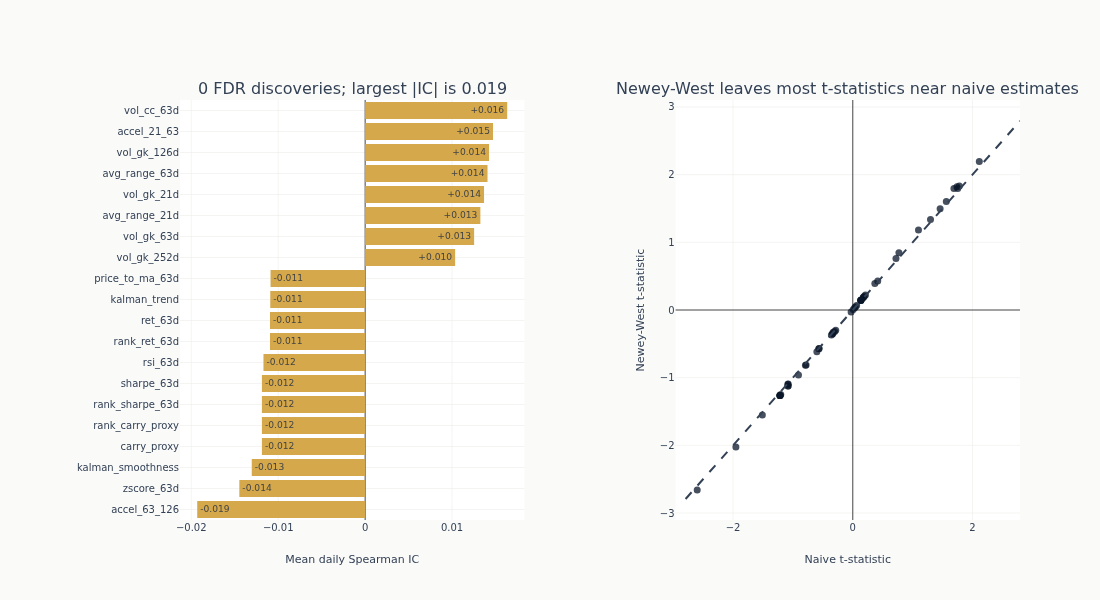

In [16]:
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"],
        y=eval_summary["hac_t"],
        mode="markers",
        marker={"color": COLORS["blue"], "size": 7, "opacity": 0.75},
        text=eval_summary["feature"],
        showlegend=False,
    ),
    row=1,
    col=2,
)
finite_t = [
    abs(float(value))
    for column in ("naive_t", "hac_t")
    for value in eval_summary[column]
    if np.isfinite(value)
]
if finite_t:
    t_limit = max(finite_t) * 1.05
    fig.add_trace(
        go.Scatter(
            x=[-t_limit, t_limit],
            y=[-t_limit, t_limit],
            mode="lines",
            line={"color": COLORS["neutral"], "dash": "dash"},
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(height=600, width=1100, margin={"l": 180})
fig.update_xaxes(title_text="Mean daily Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Naive t-statistic", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t-statistic", row=1, col=2)
fig.show()

## 5. Cross-Sectional Shape

Quantile membership is assigned within each date, never from the pooled
validation distribution. This preserves the cross-sectional question asked by
daily IC and avoids using future distributional information.

In [17]:
shape_features = eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list()[:12]
if not shape_features:
    shape_features = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feature in shape_features:
    valid = eval_panel.select([DATE_COL, feature, LABEL_COL]).drop_nulls()
    valid = valid.filter(pl.len().over(DATE_COL) >= N_QUANTILES)
    if len(valid) < N_QUANTILES * 20:
        continue
    shaped = valid.with_columns(
        (
            (pl.col(feature).rank(method="average").over(DATE_COL) - 1)
            * N_QUANTILES
            / pl.len().over(DATE_COL)
        )
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile")
    )
    q_means = shaped.group_by("quantile").agg(pl.col(LABEL_COL).mean()).sort("quantile")
    if len(q_means) != N_QUANTILES:
        continue
    means = q_means[LABEL_COL].to_list()
    quantile_spreads[feature] = means
    monotonicity_scores[feature] = float(spearmanr(range(N_QUANTILES), means).statistic)

print(f"Cross-sectional shape evaluated for {len(quantile_spreads)} features")

Cross-sectional shape evaluated for 10 features


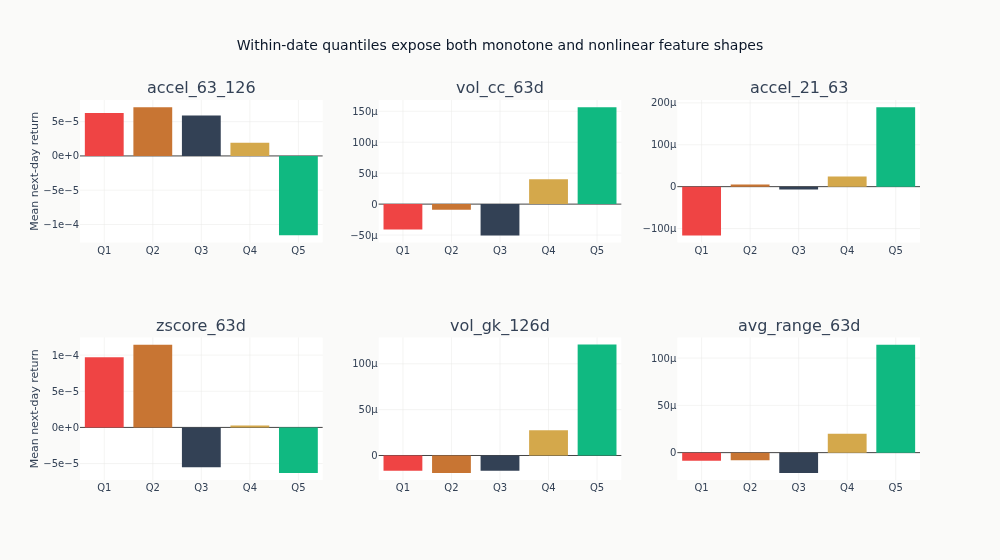

In [18]:
if quantile_spreads:
    features_to_show = list(quantile_spreads)[:6]
    figure_rows = (len(features_to_show) + 2) // 3
    fig = make_subplots(rows=figure_rows, cols=3, subplot_titles=features_to_show)
    quantile_colors = [
        COLORS["negative"],
        COLORS["copper"],
        COLORS["neutral"],
        COLORS["amber"],
        COLORS["positive"],
    ]
    for index, feature in enumerate(features_to_show):
        row, column = divmod(index, 3)
        fig.add_trace(
            go.Bar(
                x=[f"Q{quantile + 1}" for quantile in range(N_QUANTILES)],
                y=quantile_spreads[feature],
                marker_color=quantile_colors,
                showlegend=False,
            ),
            row=row + 1,
            col=column + 1,
        )
    fig.update_layout(
        title="Within-date quantiles expose both monotone and nonlinear feature shapes",
        height=280 * figure_rows,
        width=1000,
    )
    for row in range(1, figure_rows + 1):
        fig.update_yaxes(title_text="Mean next-day return", tickformat=".0e", row=row, col=1)
    fig.show()

## 6. Redundancy and Feature Families

Correlations are sampled across validation dates. A ranked pair chart exposes
the strongest redundancies without compressing 50-plus labels into an
unreadable heatmap.

In [19]:
def assign_feature_family(feature_name: str) -> str:
    """Map an FX feature to its economic or modeling family."""
    family_map = [
        (["kalman_"], "temporal_kalman"),
        (["hmm_"], "temporal_regime"),
        (["arima_"], "temporal_arima"),
        (["rank_"], "cross_sectional"),
        (["zscore", "channel_pos", "mom_skip"], "mean_reversion"),
        (["ret_"], "momentum"),
        (["vol_gk", "vol_cc", "vol_ratio", "avg_range"], "volatility"),
        (["sharpe_", "accel_"], "risk_adjusted"),
        (["usd_factor", "usd_beta"], "usd_factor"),
        (["rsi", "bollinger", "price_to_ma"], "technical"),
        (["carry"], "carry_proxy"),
        (["max_dd"], "drawdown"),
    ]
    lowered = feature_name.lower()
    for prefixes, family in family_map:
        if any(prefix in lowered for prefix in prefixes):
            return family
    return "other"

In [20]:
families = {feature: assign_feature_family(feature) for feature in all_feature_cols}
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
correlation_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(
    evaluable_features
)
correlation_matrix = correlation_data.to_pandas().corr(method="spearman")

high_correlation_pairs = []
for left_index in range(len(correlation_matrix)):
    for right_index in range(left_index + 1, len(correlation_matrix)):
        correlation = float(correlation_matrix.iloc[left_index, right_index])
        if np.isfinite(correlation) and abs(correlation) > 0.70:
            high_correlation_pairs.append(
                {
                    "pair": (
                        f"{correlation_matrix.columns[left_index]} / "
                        f"{correlation_matrix.columns[right_index]}"
                    ),
                    "correlation": correlation,
                }
            )

high_correlation_pairs.sort(key=lambda row: abs(row["correlation"]), reverse=True)
print(f"Feature pairs with |correlation| > 0.70: {len(high_correlation_pairs)}")

Feature pairs with |correlation| > 0.70: 175


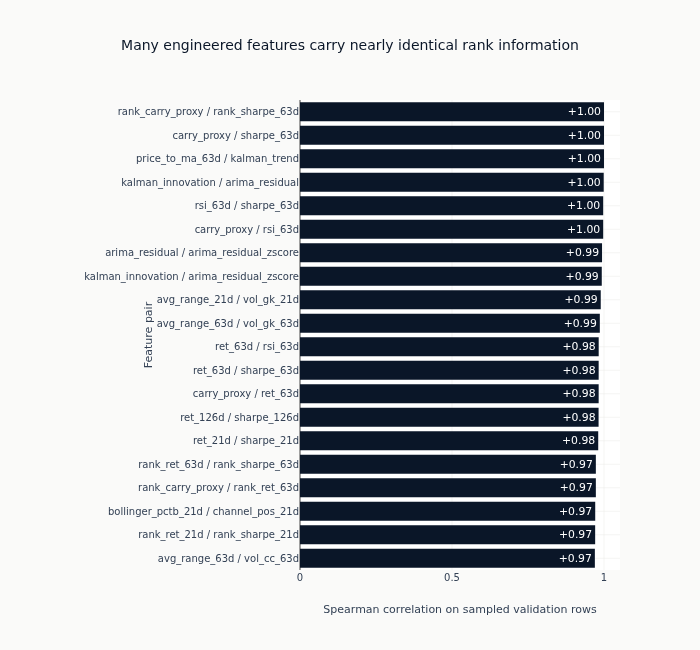

In [21]:
if high_correlation_pairs:
    correlation_plot = pl.DataFrame(high_correlation_pairs[:20]).sort("correlation")
    fig = go.Figure(
        go.Bar(
            x=correlation_plot["correlation"],
            y=correlation_plot["pair"],
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"]
                for value in correlation_plot["correlation"]
            ],
            text=[f"{value:+.2f}" for value in correlation_plot["correlation"]],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="Many engineered features carry nearly identical rank information",
        xaxis_title="Spearman correlation on sampled validation rows",
        yaxis_title="Feature pair",
        height=650,
        margin={"l": 300},
    )
    fig.show()

## 7. Diagnostic Triage

`PROCEED` means a feature merits multivariate evaluation. It is not a final
model-selection decision. `STOP` is reserved for failed correctness screens;
market-level variables and weak standalone associations remain available for
interactions under `REVISE`.

In [22]:
fdr_significant = set(eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list())
triage = {}
for feature in all_feature_cols:
    if not correctness[feature]:
        triage[feature] = ("STOP", "correctness_fail")
    elif feature in date_level_features:
        triage[feature] = ("REVISE", "date_level_conditioner")
    elif feature not in ic_results:
        triage[feature] = ("REVISE", "insufficient_validation_data")
    elif feature in fdr_significant:
        triage[feature] = ("PROCEED", "fdr_significant")
    elif (
        fold_stats.get(feature, {}).get("sign_consistency", 0) >= 0.60
        and abs(ic_results[feature]["mean_ic"]) >= IC_THRESHOLD
    ):
        triage[feature] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feature] = ("REVISE", "weak_standalone_association")

### Persist the Diagnostic Ledger

The ledger retains every component behind the decision, including direction,
fold consistency, multiplicity adjustment, coverage, and staleness.

In [23]:
ledger_rows = []
for feature in all_feature_cols:
    decision, note = triage[feature]
    summary_match = eval_summary.filter(pl.col("feature") == feature)
    ledger_rows.append(
        {
            "feature": feature,
            "family": families[feature],
            "source": "model_based" if feature in temporal_cols else "financial",
            "ic_mean": ic_results.get(feature, {}).get("mean_ic"),
            "hac_t": ic_results.get(feature, {}).get("t_stat"),
            "hac_p": ic_results.get(feature, {}).get("p_value"),
            "fdr_p": summary_match["fdr_p"][0] if len(summary_match) else None,
            "fdr_sig": bool(summary_match["fdr_sig"][0]) if len(summary_match) else False,
            "fold_direction": fold_stats.get(feature, {}).get("direction"),
            "sign_consistency": fold_stats.get(feature, {}).get("sign_consistency"),
            "worst_fold_ic": fold_stats.get(feature, {}).get("worst_fold_ic"),
            "monotonicity": monotonicity_scores.get(feature),
            "coverage": coverage[feature],
            "staleness": staleness[feature],
            "decision": decision,
            "note": note,
        }
    )

triage_ledger = pl.DataFrame(ledger_rows).sort(["decision", "feature"])
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")

ic_frames = [
    series.with_columns(pl.lit(feature).alias("feature"))
    for feature, series in ic_timeseries.items()
]
if ic_frames:
    pl.concat(ic_frames).select(["feature", DATE_COL, "fold", "ic", "n_obs"]).write_parquet(
        EVAL_DIR / "ic_timeseries.parquet"
    )

print("Wrote evaluation/triage_ledger.parquet")
print("Wrote evaluation/ic_timeseries.parquet")
print(triage_ledger.group_by("decision").len().sort("decision"))

Wrote evaluation/triage_ledger.parquet
Wrote evaluation/ic_timeseries.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 27  │
│ REVISE   ┆ 29  │
│ STOP     ┆ 5   │
└──────────┴─────┘


## Key Takeaways

The result below is generated from the sealed validation panel so it cannot
drift away from the executed evidence.

In [24]:
proceed_features = [feature for feature, (decision, _) in triage.items() if decision == "PROCEED"]
revise_features = [feature for feature, (decision, _) in triage.items() if decision == "REVISE"]
stop_features = [feature for feature, (decision, _) in triage.items() if decision == "STOP"]
leader = eval_summary.row(0, named=True) if len(eval_summary) else None

if leader:
    result = (
        f"**Result.** Across **{eval_panel['fold'].n_unique()} canonical validation folds**, "
        f"**{n_fdr} of {len(eval_summary)} cross-sectional features survive BH-FDR at 5%**. "
        f"The largest absolute estimate is `{leader['feature']}` "
        f"(mean daily IC {leader['ic_mean']:+.4f}, Newey-West t {leader['hac_t']:+.2f}). "
        f"The diagnostic ledger assigns **{len(proceed_features)} PROCEED**, "
        f"**{len(revise_features)} REVISE**, and **{len(stop_features)} STOP** decisions."
    )
else:
    result = "**Result.** The reduced run did not contain enough pairs for cross-sectional IC."

display(Markdown(result))

**Result.** Across **8 canonical validation folds**, **0 of 51 cross-sectional features survive BH-FDR at 5%**. The largest absolute estimate is `accel_63_126` (mean daily IC -0.0193, Newey-West t -2.02). The diagnostic ledger assigns **27 PROCEED**, **29 REVISE**, and **5 STOP** decisions.

`PROCEED` features advance only to multivariate validation. Date-level HMM and
USD variables remain conditioning candidates, while strongly correlated
feature clusters call for regularization rather than duplicate evidence.

**Next**: `06_linear.py` evaluates linear models on the same canonical folds.